# Deep Q-Learning Sensor Placement

Harris corner detection places outer sensors first. `SensorDRL` then trains a DQN policy that sequentially places inner sensors.

In [8]:
from Analysis.visualization import VisualTool
from Engine.map_loader import MapLoader
from Engine.masks import layer_map
from InnerDeployment.DRL.main import SensorDRL
from OuterDeployment.HarrisCorner import HarrisCorner

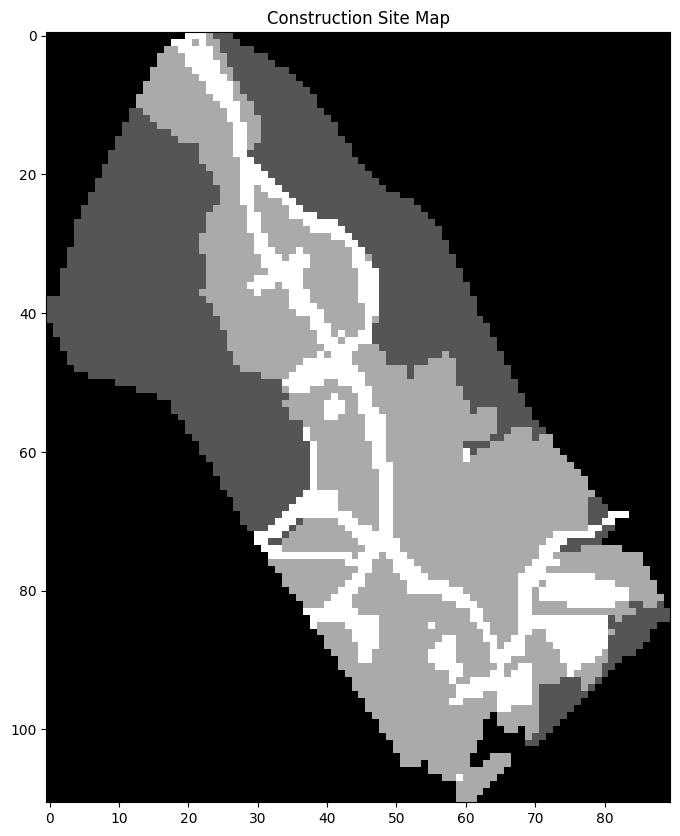

Saved figure: __RESULTS__/_plots/06-02-03-04/construction_map.png


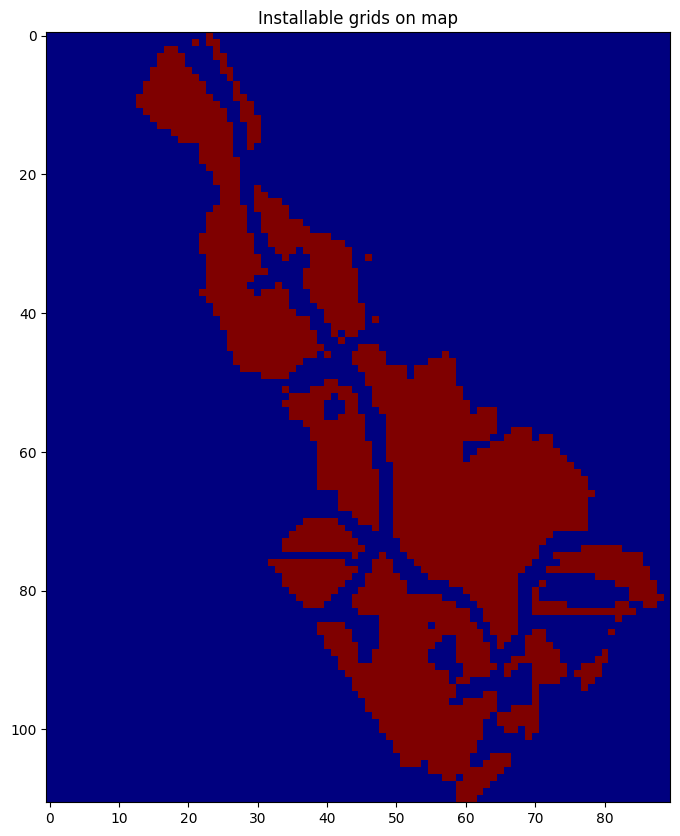

Saved figure: __RESULTS__/_plots/06-02-03-04/installable_map.png


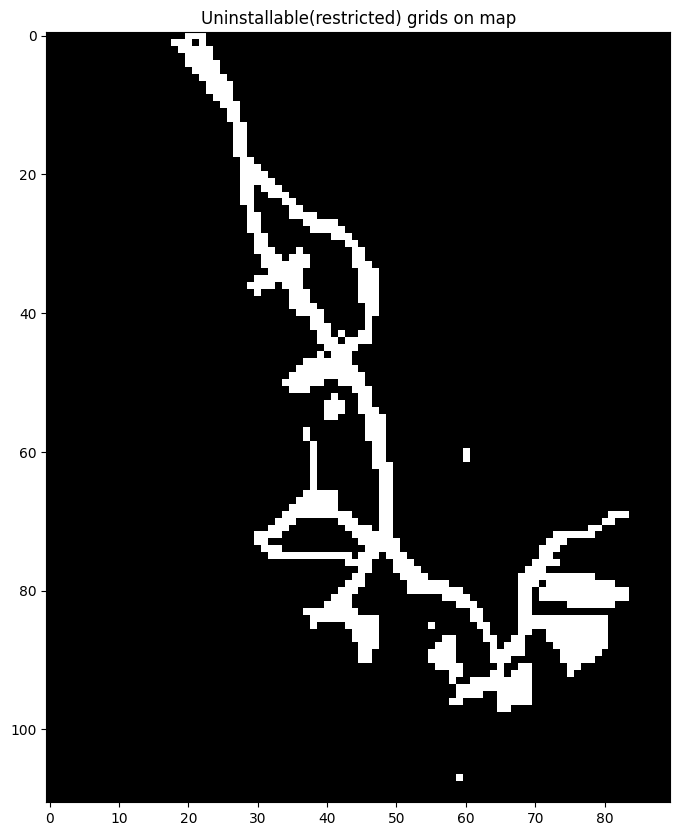

Saved figure: __RESULTS__/_plots/06-02-03-04/restricted_map.png


In [9]:
vis = VisualTool(show=True, size=(10, 10), save=True, dpi=100, save_dir="__RESULTS__/_plots")
map_data = MapLoader().load("gangjin/full")

installable_layer = layer_map(map_data, keep_values=[2])
road_layer = layer_map(map_data, keep_values=[3])
jobsite_layer = layer_map(map_data, keep_values=[2, 3])

vis.showMap(map_data=map_data, title="Construction Site Map", cmap="gray", filename="construction_map")
vis.showMap(map_data=installable_layer, title="Installable grids on map", cmap="jet", filename="installable_map")
vis.showMap(map_data=road_layer, title="Uninstallable(restricted) grids on map", cmap="gray", filename="restricted_map")

Outmost corner points: 8


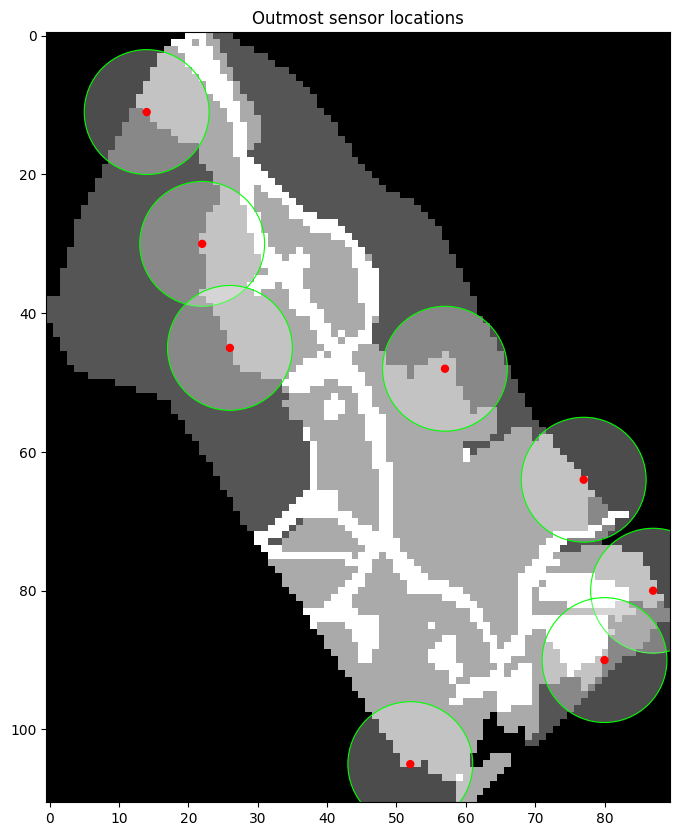

Saved figure: __RESULTS__/_plots/06-02-03-04/corner_sensors.png


In [10]:
COVERAGE = 45

corner_candidate = HarrisCorner(jobsite_layer).run(
    grid=jobsite_layer,
    installable_layer=installable_layer,
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=corner_candidate,
    title="Outmost sensor locations",
    radius=COVERAGE,
    cmap="gray",
    filename="corner_sensors",
)

In [11]:
drl = SensorDRL(
    installable_map=installable_layer,
    jobsite_map=jobsite_layer,
    coverage=COVERAGE,
    generations=100,
    corner_positions=corner_candidate,
    min_sensors=0,
    max_sensors=140,
    candidate_stride=5,
    max_candidates=512,
    hidden_dim=128,
    replay_capacity=5000,
    batch_size=64,
    learning_rate=1e-3,
    gamma=0.95,
    target_sync_interval=100,
    warmup_steps=64,
    train_steps_per_action=1,
    backup_actions=64,
    fitness_kwargs={"target_coverage": 90.0},
)

optimized_result = drl.run(
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.985,
    heuristic_warmup_episodes=1,
    return_best_only=True,
)

[DRL 001/100] inner=10 / coverage=90.73% / reward=71.301 / loss=nan / epsilon=1.000 / time=0.010s
[DRL 002/100] inner=25 / coverage=90.18% / reward=67.750 / loss=nan / epsilon=0.985 / time=0.022s
[DRL 003/100] inner=25 / coverage=91.87% / reward=69.438 / loss=nan / epsilon=0.970 / time=0.024s
[DRL 004/100] inner=26 / coverage=92.11% / reward=69.480 / loss=2.56303 / epsilon=0.956 / time=0.148s
[DRL 005/100] inner=29 / coverage=91.49% / reward=68.259 / loss=1.93527 / epsilon=0.941 / time=0.176s
[DRL 006/100] inner=24 / coverage=90.28% / reward=68.053 / loss=1.77715 / epsilon=0.927 / time=0.150s
[DRL 007/100] inner=25 / coverage=91.76% / reward=69.335 / loss=1.63782 / epsilon=0.913 / time=0.157s
[DRL 008/100] inner=25 / coverage=90.14% / reward=67.715 / loss=1.89775 / epsilon=0.900 / time=0.152s
[DRL 009/100] inner=24 / coverage=90.66% / reward=68.432 / loss=1.46217 / epsilon=0.886 / time=0.142s
[DRL 010/100] inner=19 / coverage=90.76% / reward=69.536 / loss=1.41460 / epsilon=0.873 / time

In [12]:
print("[FINALIZE OUTPUT] drl.best_solution =", drl.best_solution)
print("[FINALIZE OUTPUT] len(drl.best_solution) =", len(drl.best_solution))
print("[FINALIZE OUTPUT] drl.corner_points =", drl.corner_points)
print("[FINALIZE OUTPUT] len(drl.corner_points) =", len(drl.corner_points))

[FINALIZE OUTPUT] drl.best_solution = [(64, 80), (47, 70), (49, 87), (42, 51), (37, 34), (62, 63), (62, 96), (36, 76), (29, 15), (75, 75)]
[FINALIZE OUTPUT] len(drl.best_solution) = 10
[FINALIZE OUTPUT] drl.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(drl.corner_points) = 8


Total number of Sensor: 18


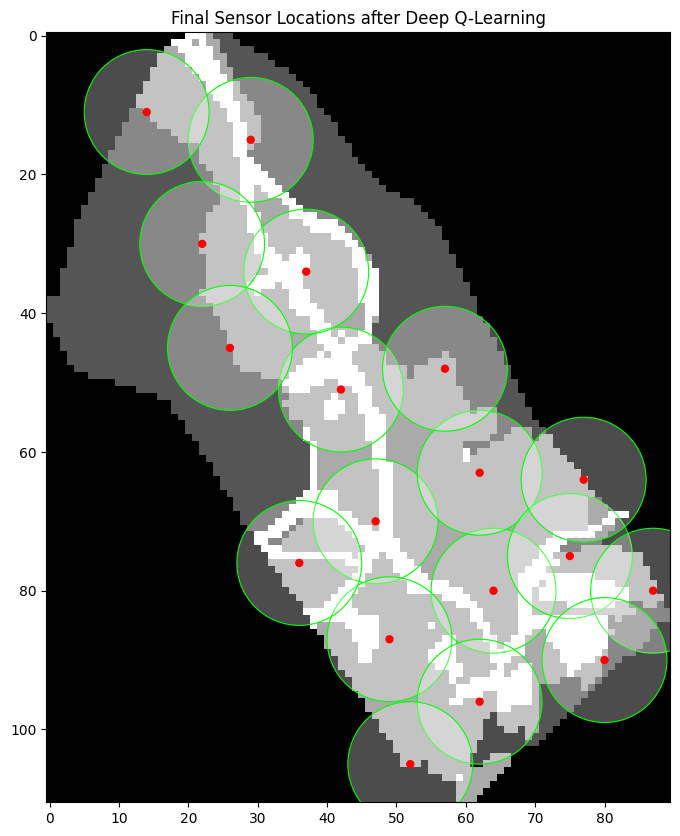

Saved figure: __RESULTS__/_plots/06-02-03-04/final_sensors_drl.png


In [13]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor:", len(final_result))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=final_result,
    title="Final Sensor Locations after Deep Q-Learning",
    radius=COVERAGE,
    cmap="gray",
    filename="final_sensors_drl",
)